In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the prepared baseline for the comparisons below.
baseline = ds.pipeline.open(label="docs_default")
# Reuse the run's frozen analysis cells.
cell_selection = baseline["analysis_cell_selection"]
# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

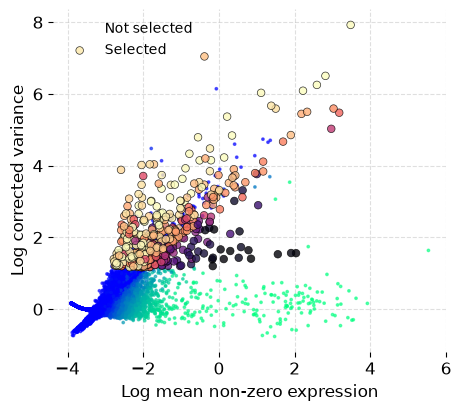

{'matches docs_default': True, 'selected genes': 500}

In [3]:
# Select the same 500 genes used by the prepared baseline.
hvg_500 = ds.select_hvgs(cell_selection, top_n=500)
# Load the selected-gene mask on the full feature axis.
hvg_500_values = np.asarray(ds.load_artifact(hvg_500)["values"][:])
# Check agreement with the saved selection and its gene count.
{
    "matches docs_default": hvg_500 == baseline["highly_variable_features"],
    "selected genes": int(hvg_500_values.sum()),
}

In [4]:
from scarf.features.gene_families import GENE_FAMILY_PATTERNS
from scarf.features.variability import DEFAULT_HVG_BLACKLIST

# Count genes matching each default exclusion family.
family_counts = pd.Series(
    {
        name: len(ds.RNA.feats.grep(pattern))
        for name, pattern in GENE_FAMILY_PATTERNS.items()
    },
    name="genes matching pattern",
)
# Count all genes matched by the combined default blacklist.
print("Default blacklist matches:", len(ds.RNA.feats.grep(DEFAULT_HVG_BLACKLIST)))
# Inspect which excluded gene families are represented in the assay.
family_counts

Default blacklist matches: 329


mitochondrial     13
ribosomal        184
cellCycleCcn      31
hla               20
h2                 0
histone           71
sexLinked         10
Name: genes matching pattern, dtype: int64

In [5]:
# Repeat selection with the same count and no name blacklist.
hvg_no_blacklist = ds.select_hvgs(
    cell_selection, top_n=500, blacklist="", show_plot=False
)
# Load the alternative selection on the same feature axis.
unblocked_values = np.asarray(ds.load_artifact(hvg_no_blacklist)["values"][:])
# Keep both feature masks for a direct comparison.
selection_values = {
    "hvgs_default": hvg_500_values,
    "hvgs_no_blacklist": unblocked_values,
}
# Compare selected-gene counts with and without name exclusions.
pd.Series(
    {key: int(values.sum()) for key, values in selection_values.items()},
    name="selected genes",
)

hvgs_default         500
hvgs_no_blacklist    500
Name: selected genes, dtype: int64

In [6]:
# Read gene names on the full feature axis.
feature_names = ds.RNA.feats.fetch_all("names")
# Keep the default selection mask.
default_values = selection_values["hvgs_default"]
# Find genes added only when the blacklist is cleared.
only_without_blacklist = feature_names[unblocked_values & ~default_values]
# Count genes added only when the blacklist is cleared.
print(
    "Genes selected only when blacklist is cleared:", len(only_without_blacklist)
)
# Inspect the newly included gene names.
pd.Series(only_without_blacklist).head(15)

Genes selected only when blacklist is cleared: 11


0     HIST1H2AC
1     HIST1H2BJ
2      HIST1H3H
3       HLA-DRA
4      HLA-DRB1
5      HLA-DQA1
6      HLA-DQB1
7       HLA-DMB
8       HLA-DMA
9      HLA-DPA1
10     HLA-DPB1
dtype: str

In [7]:
# Select 1,000 genes on the same frozen cell population.
feature_1000 = ds.select_hvgs(cell_selection, top_n=1000, show_plot=False)
# Read the selected-gene mask for the new branch.
feature_1000_values = np.asarray(ds.load_artifact(feature_1000)["values"][:])
# Check the number of genes retained for the new branch.
{"selected genes": int(feature_1000_values.sum())}

{'selected genes': 1000}

In [8]:
# Normalize the new feature selection.
normalized_1000 = ds.run_normalization(cell_selection, feature_1000)
# Keep 15 PCA dimensions for this feature-count comparison.
pca_1000 = ds.run_pca(normalized_1000, dims=15)
# Prepare the embedding initialization from the new PCA.
initialization_1000 = ds.build_embedding_initialization(pca_1000)
# Build a neighbor-search index for the new PCA.
ann_1000 = ds.build_ann_index(pca_1000)
# Keep the baseline neighbor count of 11.
neighbors_1000 = ds.query_neighbors(ann_1000, k=11)
# Build connectivity from the new neighbors.
graph_1000 = ds.build_connectivity_map(neighbors_1000)
# Read the PCA dimensions supplied to this graph without loading its values.
pca_shape = ds.load_artifact(pca_1000)["data"].shape
# Inspect the cell and principal-component counts.
{"cells": pca_shape[0], "PCs": pca_shape[1]}

{'cells': 3948, 'PCs': 15}

In [9]:
# Pair the layout and clustering for each feature count.
feature_branches = {
    500: (baseline["umap"], baseline["leiden_0.5"]),
    1000: (
        ds.run_umap(graph_1000, initialization_1000),
        ds.run_leiden_clustering(graph_1000, resolution=0.5),
    ),
}
# Read the dimensions of the saved layout for each feature count.
layout_shapes = {
    top_n: ds.load_artifact(layout_ref)["values"].shape
    for top_n, (layout_ref, _) in feature_branches.items()
}
# Check that both layouts contain the same cells and two embedding coordinates.
pd.DataFrame(
    layout_shapes, index=["cells", "embedding dimensions"]
).T.rename_axis("selected genes")

,cells,embedding dimensions
selected genes,,
500,3948,2
1000,3948,2


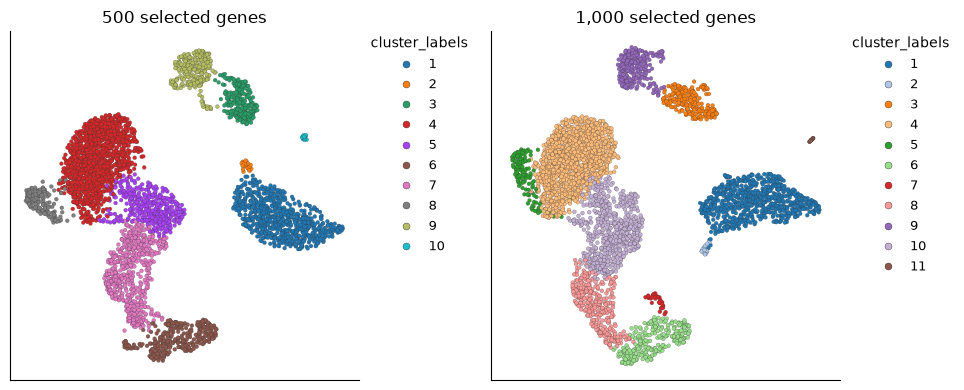

In [10]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
# Retain the cluster labels from each plotted feature branch.
cluster_values = {}
# Draw each comparison on its own labeled axis.
for axis, top_n in zip(axes, feature_branches, strict=True):
    # Select this branch's layout and cluster labels.
    umap_ref, cluster_ref = feature_branches[top_n]
    # Read the cluster labels for this branch.
    labels = np.asarray(ds.load_artifact(cluster_ref)["values"][:])
    # Retain those labels for the cross-tabulation below.
    cluster_values[top_n] = labels
    # Plot this feature branch with its corresponding clustering.
    ds.plots.embedding(
        layout=umap_ref,
        color_by=cluster_ref,
        target=axis,
        show_titles=False,
        show=False,
    )
    # Label the panel with the quantity being compared.
    axis.set_title(f"{top_n:,} selected genes")
# Adjust spacing so panel labels remain readable.
figure.tight_layout()
# Display the completed figure.
figure

In [11]:
# Read the baseline 500-gene cluster labels.
cluster_500 = cluster_values[500]
# Read the 1,000-gene cluster labels.
cluster_1000 = cluster_values[1000]
# Compare the cell counts or fractions across the selected groups.
pd.crosstab(
    pd.Series(cluster_500, name="500 genes"),
    pd.Series(cluster_1000, name="1,000 genes"),
    margins=True,
)

"1,000 genes",1,2,3,4,5,6,7,8,9,10,11,All
500 genes,,,,,,,,,,,,
1,715,1,0,0,0,0,0,0,0,0,0,716
2,2,23,0,0,0,0,0,0,0,0,0,25
3,0,0,222,0,0,0,0,0,17,0,0,239
4,0,0,0,1181,12,0,0,0,0,48,0,1241
5,0,0,0,30,0,0,0,0,0,404,0,434
6,0,0,0,0,0,282,33,4,0,0,0,319
7,0,0,0,0,0,3,1,343,0,205,0,552
8,0,0,0,20,130,0,0,1,0,0,0,151
9,0,0,9,0,0,0,0,0,247,0,0,256


In [12]:
# Quantify partition agreement between 500 and 1,000 genes.
pd.Series(
    {
        "adjusted Rand index": ds.metric_label_concordance(
            feature_branches[500][1], feature_branches[1000][1]
        )
    },
    name="500 vs 1,000 selected genes",
)

adjusted Rand index    0.8433
Name: 500 vs 1,000 selected genes, dtype: float64

In [13]:
# Choose a small marker panel for the comparison.
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
# Match the chosen genes to the complete feature axis.
manual_mask = np.isin(feature_names.astype(str), panel_genes)
# Check that the manual mask matches the assay axis and is nonempty.
print("mask length:", len(manual_mask), "selected:", int(manual_mask.sum()))
# Save the externally chosen feature selection.
custom_features = ds.set_feature_selection(mask=manual_mask)
# Inspect the reference for the saved manual gene selection.
custom_features

mask length: 33538 selected: 6


ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='6fa7a9d89c6f...')